In [17]:
import pandas as pd
df = pd.read_pickle("Main_Director_PCA filtered.pkl")

/Users/anjalarajeev/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


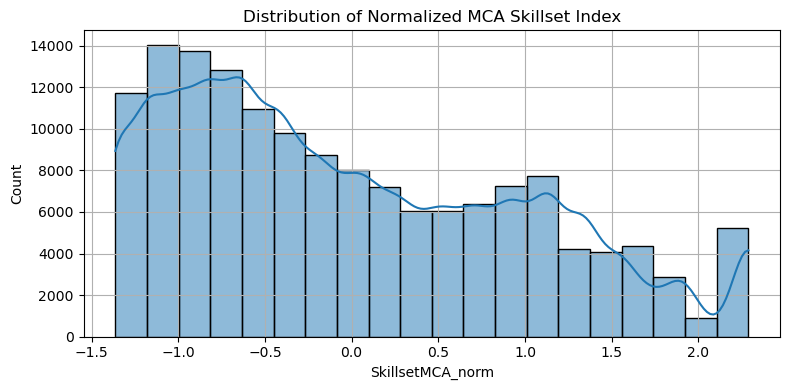

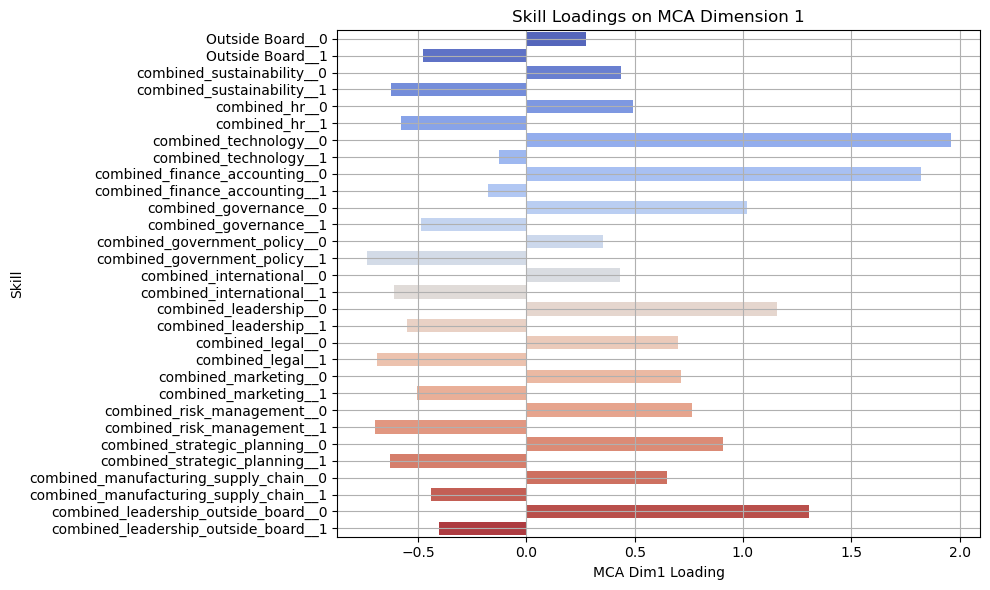

In [30]:
# Step 0: Install necessary library
# Run this in your terminal if not already installed:
# pip install prince

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import prince  # for MCA

# Step 1: Define binary skillset columns (Boolean variables)
skillset_cols = [
     #'Academic',
 'Outside Board',
 #'Company Business',
 'combined_sustainability',
 #'combined_entrepreneurial',
 #'combined_compensation',
 #'combined_conglomerate_experience',
 'combined_hr',
 'combined_technology',
 'combined_finance_accounting',
 'combined_governance',
 'combined_government_policy',
 'combined_international',
 'combined_leadership',
 'combined_legal',
 'combined_marketing',
 'combined_risk_management',
 #'combined_scientific',
 'combined_strategic_planning',
 'combined_manufacturing_supply_chain',
 'combined_leadership_outside_board',
]
# Step 2: Ensure the skillset columns are binary
X = df[skillset_cols].astype(int)

# Step 3: Fit MCA model
mca = prince.MCA(n_components=2, random_state=42)
mca_fit = mca.fit(X)

# Step 4: Get first component as skillset index
df['SkillsetMCA'] = mca_fit.transform(X)[0]

# Step 5: Normalize the index (optional but useful)
df['SkillsetMCA_norm'] = (df['SkillsetMCA'] - df['SkillsetMCA'].mean()) / df['SkillsetMCA'].std()

# Step 6: Create a generalist binary variable (e.g., above median)
median_val = df['SkillsetMCA_norm'].median()
df['SkillsetGeneralist_MCA'] = (df['SkillsetMCA_norm'] > median_val).astype(int)

# Step 7: Plot skillset distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['SkillsetMCA_norm'], kde=True, bins=20)
plt.title("Distribution of Normalized MCA Skillset Index")
plt.xlabel("SkillsetMCA_norm")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 8: Visualize MCA feature contributions (loadings)
loadings = mca_fit.column_coordinates(X)  # MCA equivalent of loadings
loadings = loadings.rename(columns={0: 'MCA_Dim1_Loading', 1: 'MCA_Dim2_Loading'})

plt.figure(figsize=(10, 6))
sns.barplot(x='MCA_Dim1_Loading', y=loadings.index, data=loadings, palette='coolwarm')
plt.title("Skill Loadings on MCA Dimension 1")
plt.xlabel("MCA Dim1 Loading")
plt.ylabel("Skill")
plt.grid(True)
plt.tight_layout()
plt.show()


In [31]:
from sklearn.decomposition import PCA

# Example: perform PCA on skillset columns (or some numeric data)
X_numeric = df[skillset_cols].astype(int)

# Fit PCA with all components (or specify n_components)
pca_full = PCA(n_components=len(skillset_cols), random_state=42)
pca_full.fit(X_numeric)

print("PCs with eigen value and Explained Variance:")
x = 0
cum_explained_variance = 0
for i, eigenvalue in enumerate(pca_full.explained_variance_):
    print(f"PC {i+1:<5} : {eigenvalue:<8.3f} ::: {pca_full.explained_variance_ratio_[i]*100:.2f} %")
    if eigenvalue > 1:
        x += 1
        cum_explained_variance += pca_full.explained_variance_ratio_[i]*100

print(f"\nCumulative Explained Variance of eligible PCs (eigen value > 1):")
print(f"Top {x} PCs cumulative explained variance = {cum_explained_variance:.2f}%")


PCs with eigen value and Explained Variance:
PC 1     : 1.235    ::: 39.03 %
PC 2     : 0.251    ::: 7.92 %
PC 3     : 0.209    ::: 6.61 %
PC 4     : 0.199    ::: 6.30 %
PC 5     : 0.188    ::: 5.95 %
PC 6     : 0.184    ::: 5.82 %
PC 7     : 0.165    ::: 5.21 %
PC 8     : 0.150    ::: 4.75 %
PC 9     : 0.136    ::: 4.31 %
PC 10    : 0.118    ::: 3.74 %
PC 11    : 0.108    ::: 3.40 %
PC 12    : 0.099    ::: 3.11 %
PC 13    : 0.073    ::: 2.32 %
PC 14    : 0.025    ::: 0.80 %
PC 15    : 0.024    ::: 0.75 %

Cumulative Explained Variance of eligible PCs (eigen value > 1):
Top 1 PCs cumulative explained variance = 39.03%
